## In the below code, I will be evaluating the predictive capabilities of three different time-series forecasting models (ARIMA, SAMIRA, and Meta's Prophet) on a timeseries data set of copper prices. 

#### Following traditional data-science protocols, I will be splitting my time-series data into "train" and "test" segments, and calculating the RMSE of the predicted dataset vs. the observed "test" values to evaluate the model's predictive capabilities. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [2]:
df = pd.read_csv('copper-prices-historical-data.csv', index_col='date', parse_dates=True).asfreq('D').loc['2021-01-01':]
# I decided to grab data starting from 2021 as the supply/chain disruption due to COVID greatly influenced the commodity's price increase from 2019-2020

df.rename(columns={' value': 'value'}, inplace=True)

df.head()

,value
date,
2021-01-01,NaN
2021-01-02,NaN
2021-01-03,NaN
2021-01-04,3.5545
2021-01-05,3.6395


Cleaning / visualising the data set

In [6]:
df = df.fillna(method='bfill')
df.isna().sum()

value    0
dtype: int64

,value
count,1295.000000
mean,4.065911
std,0.381225
min,3.227200
25%,3.770550
50%,4.052800
75%,4.369700
max,5.105600


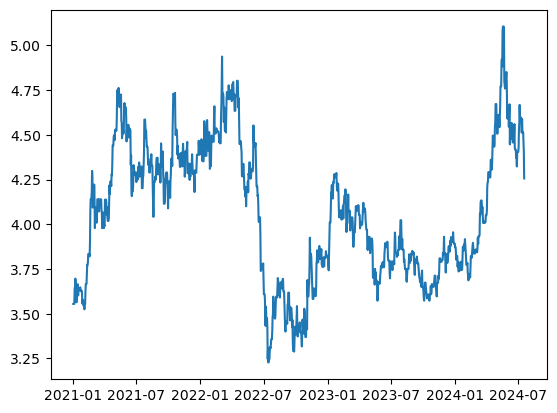

In [7]:
plt.plot(df)

df.describe()

# Method 1: ARIMA

The ARIMA model is a powerful tool time series forecasting, capable of handling a wide range of data patterns by incorporating autoregression, differencing, and moving averages. Its effectiveness relies on correctly identifying the appropriate parameters (p,d,q) for a specific time- which requires discretion. 

In [8]:
# as you can see visually from the chart, above, the data is clearly not stationary- but we can apply a statistical test to prove this as well

from statsmodels.tsa.stattools import adfuller

X = df.values 
result = adfuller(X)
print('p-value:', result[1])

if result[1] <= 0.05:
    print('The time series is likely stationary.')
else:
    print('The time series is likely non-stationary.')

p-value: 0.08906923030637681
The time series is likely non-stationary.


<Axes: xlabel='date'>

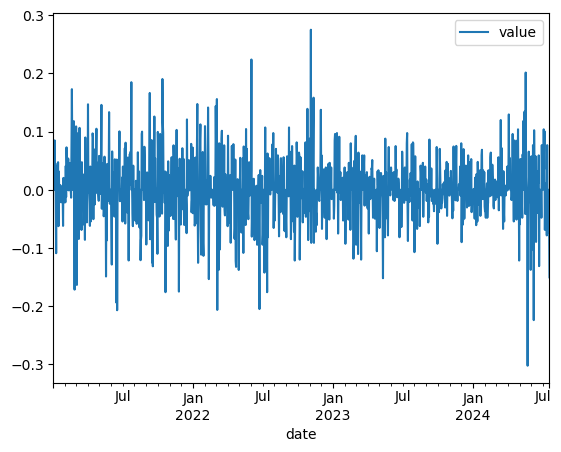

In [9]:
# now that we have proved its non-stationary, we need to difference the data to make it stationary
df_differenced = df.diff().dropna()
df_differenced.plot()

In [10]:
#re-running test to ensure data is stationary

result = adfuller(df_differenced)
print('p-value:', result[1])

if result[1] <= 0.05:
    print('The time series is likely stationary.')
else:
    print('The time series is likely non-stationary.')

p-value: 0.0
The time series is likely stationary.


note that we only had to difference the data 1 time to achieve stationarity, therefore parameter d = 1

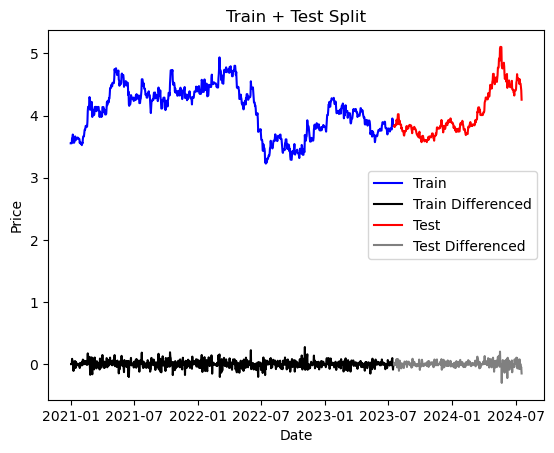

In [11]:
#we have about 3 years of data, I am going to use the first two years to train to test on the most recent year of data

train_end = "2023-07-18"
train_differenced = df_differenced[df_differenced.index < train_end]
train = df[df.index < train_end]

test_differenced = df_differenced[df_differenced.index >= train_end]
test = df[df.index >= train_end]


plt.plot(train, color="blue", label="Train")
plt.plot(train_differenced, color="black", label="Train Differenced")
plt.plot(test, color="red", label="Test")
plt.plot(test_differenced, color="grey", label="Test Differenced")
plt.ylabel('Price')
plt.xlabel('Date')
plt.title("Train + Test Split")
plt.legend()
plt.show()

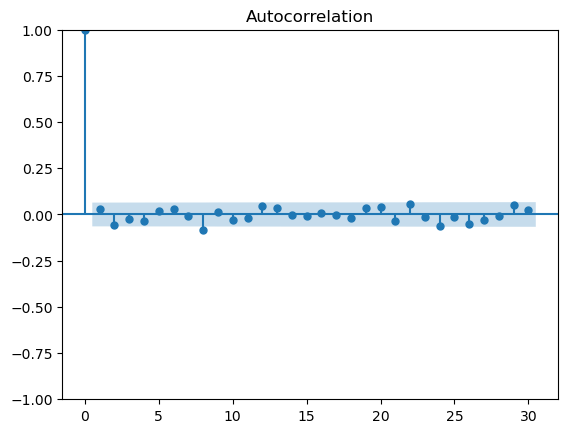

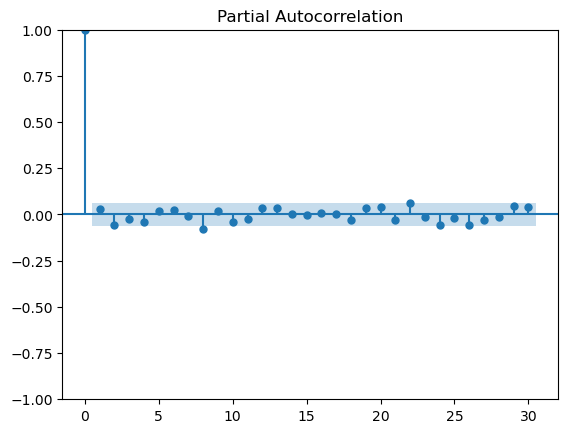

In [12]:
# we already have parameter d = 1, ARIMA(p,1,q), now need to solve for p and q
# looking for spikes significantly beyond confidence intervals

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf = plot_acf(train_differenced)
pacf = plot_pacf(train_differenced)

I see 1 large spike beyond the confidence intervals on each graph so I am going to determine that the correct parameters for this model are (1, 1, 1)

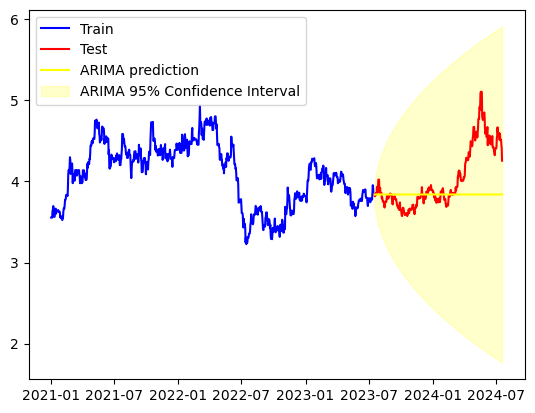

In [13]:
from statsmodels.tsa.arima.model import ARIMA as ARIMA

ARIMA = ARIMA(train, order=(1,1,1))
ARIMA_fit = ARIMA.fit()

ARIMAforecast=ARIMA_fit.get_forecast(len(test))
ARIMAforecast_mean= ARIMAforecast.predicted_mean
ARIMAconfidence_interval = ARIMAforecast.conf_int()


plt.plot(train, color = "blue", label="Train")
plt.plot(test, color = "red", label="Test")

plt.plot(ARIMAforecast_mean.index, ARIMAforecast_mean, color="yellow", label="ARIMA prediction")
plt.fill_between(ARIMAconfidence_interval.index, ARIMAconfidence_interval.iloc[:, 0], ARIMAconfidence_interval.iloc[:, 1], color='yellow', alpha=0.2, label='ARIMA 95% Confidence Interval')

plt.legend()


The ARIMA model produces a (seemingly) straight line when plotted against the "test" data, though the actual observed data points do fall within the model's 95% confidence interval. To mathematically evaluate the model, we need to compare its RMSE vs. other models

In [14]:
import math

from sklearn.metrics import mean_squared_error

mse1 = mean_squared_error(test['value'], ARIMAforecast_mean)

rmse1 = math.sqrt(mse1)

print('RMSE ARIMA: ' +str(rmse1))


RMSE ARIMA: 0.4151211626072702


# Method #2: SARIMA Model 

SARIMA is an ARIMA model that includes seasonal components, making it suitable for time series data with repeating patterns or seasonality. Metals often have seasonality due to factors like weather, harvest cycles, and market demand variations, so I believe it would be appropriate to use on this data set. 

In [15]:
import statsmodels.api as SARIMA
SARIMA=SARIMA.tsa.statespace.SARIMAX(train,order=(1, 1, 1),seasonal_order=(1,1,1,12))
SARIMA_fit=SARIMA.fit()


SARIMAforecast=SARIMA_fit.get_forecast(len(test))

SARIMAforecast_mean= SARIMAforecast.predicted_mean
confidence_interval = SARIMAforecast.conf_int()


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.34130D+00    |proj g|=  5.13307D+00


 This problem is unconstrained.



At iterate    5    f= -1.39340D+00    |proj g|=  1.47340D-01

At iterate   10    f= -1.40654D+00    |proj g|=  6.05205D-01

At iterate   15    f= -1.40868D+00    |proj g|=  5.95221D-01

At iterate   20    f= -1.43928D+00    |proj g|=  2.54953D-01

At iterate   25    f= -1.44662D+00    |proj g|=  2.76172D-02

At iterate   30    f= -1.44757D+00    |proj g|=  1.89652D-02

At iterate   35    f= -1.44862D+00    |proj g|=  6.22182D-03

At iterate   40    f= -1.44889D+00    |proj g|=  1.62242D-03

At iterate   45    f= -1.44890D+00    |proj g|=  1.36036D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     48     72   

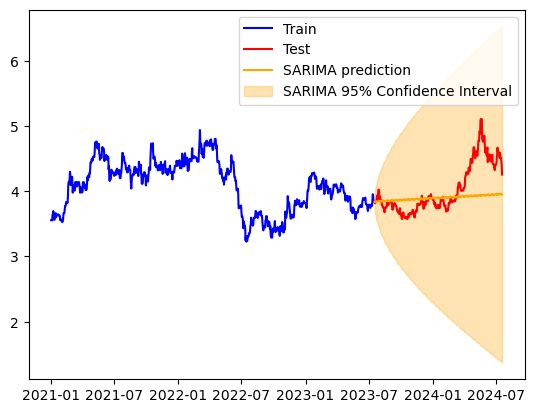

In [16]:
plt.plot(train, color="blue", label="Train")
plt.plot(test, color="red", label="Test")

plt.plot(SARIMAforecast_mean.index, SARIMAforecast_mean, color="orange", label="SARIMA prediction")
plt.fill_between(confidence_interval.index, confidence_interval.iloc[:, 0], confidence_interval.iloc[:, 1], color='orange', alpha=0.3, label='SARIMA 95% Confidence Interval')


plt.legend()

The SARIMA prediction line seems to have some slope to it which is encouraging, though the confidence interval appears wider. Let's compare the SARIMA model's RSME vs. the ARIMA model's RSME. 

In [17]:
mse2 = mean_squared_error(test, SARIMAforecast_mean)

rmse2 = math.sqrt(mse2)

print('RMSE SARIMA: ' +str(rmse2))
print('RMSE ARIMA: ' +str(rmse1))


RMSE SARIMA: 0.36816908229982365
RMSE ARIMA: 0.4151211626072702


As I had expected, the SARIMA model seems to have greater predictive capabilities on this data set than the ARIMA model, as seen by its lower RSME

# Method 3: Meta's "Prophet" Forecasting Model

In [18]:
from prophet import Prophet

df.reset_index(inplace=True)

df.rename(columns={'date': 'ds', 'value': 'y'}, inplace=True) #weird quirk of the Prophet model, you have to re-name your columns

df['ds'] = pd.to_datetime(df['ds'], errors='coerce')

In [19]:
train_end = "2023-07-18"
train = df[df['ds'] < train_end]
test = df[df['ds'] >= train_end]


In [20]:
model = Prophet()

model = model.fit(train)

future = model.make_future_dataframe(periods=len(test))
future = future[future['ds'] >= train_end]
forecast = model.predict(future)


18:30:23 - cmdstanpy - INFO - Chain [1] start processing
18:30:23 - cmdstanpy - INFO - Chain [1] done processing


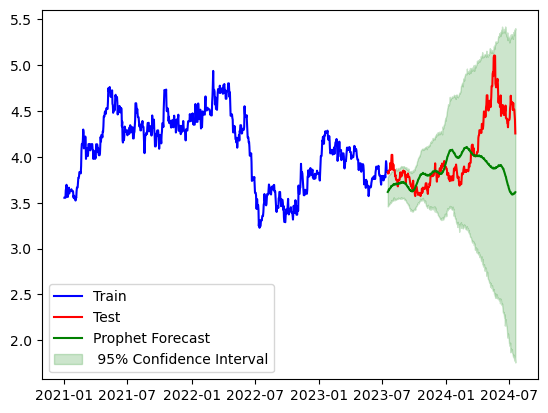

In [21]:
plt.plot(train['ds'], train['y'], color="blue", label='Train')
plt.plot(test['ds'], test['y'], color= "red", label='Test')
plt.plot(forecast['ds'], forecast['yhat'], color="green", label='Prophet Forecast')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='green', alpha=0.2, label=' 95% Confidence Interval')
plt.legend()
plt.show()

In [33]:
mse3 = mean_squared_error(test['y'], forecast['yhat'])

rmse3 = math.sqrt(mse3)

print('RMSE Prophet: ' +str(rmse3))


RMSE Prophet: 0.42622588646339377


In [37]:
results = rmse1, rmse2, rmse3

model_names = ['ARIMA', 'SARIMA', 'Prophet']

df_results = pd.DataFrame({'Model': model_names, 'RMSE': results})
df_results.set_index('Model', inplace=True)

print(df_results)

             RMSE
Model            
ARIMA    0.415121
SARIMA   0.368169
Prophet  0.426226


Of the three models models explored,the SARIMA model produced the lowest RMSE which can be interpreted as it having the most accurate predictive capabilities.
